In [35]:
from pathlib import Path
import math
import shutil
import sys
import tempfile

import duckdb
import yaml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyfolio as pf
import vectorbtpro as vbt
import xgboost as xgb
from IPython.display import display

repo_root = Path.cwd().resolve()
if not (repo_root / "qts").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


START_DATE = pd.Timestamp("2018-01-01").date()
END_DATE = pd.Timestamp("2026-05-31").date()
BENCHMARK = "VN:VNINDEX"
INIT_CASH = 100_000_000
FEE_RATE = 0.0015

FORWARD_PERIOD = 12
CLASSIFICATION_WINDOW = 120
TRAIN_WINDOW = 630
REBALANCE_FREQUENCY = 8
MAX_POSITIONS = 5
MIN_FEATURE_COUNT = 3

CLASS_QUANTILES = [0.15, 0.45, 0.60, 0.85]
CLASS_SCORES = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
CLASS_PROB_COLS = [f"class_{i}_prob" for i in range(5)]
SIGNAL_PROB_COLS = ["class_3_prob", "class_4_prob"]
SIGNAL_PROB_SUM_COL = "class_3_4_prob"
SIGNAL_THRESHOLD = 0.40
FALLBACK_MIN_POSITIONS = 1
RANK_COL = "class_4_prob"

PREDICTOR_COLS = [
    "close_macd_histogram_50_200_30",
    "close_qsmom_21_252_126",
    "close_roc_0_63",
    "close_roc_0_252",
    "close_rsi_63",
    "close_fip_momentum_252",
    "close_volatility_annualized_252",
]
TARGET_COL = f"Return_fwd_{FORWARD_PERIOD}"

XGB_PARAMS = dict(
    n_estimators=5,
    learning_rate=0.1,
    max_depth=3,
    n_jobs=-1,
    random_state=123,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
)

TEST_INTERVALS = [
    (pd.Timestamp("2021-01-01"), pd.Timestamp("2023-01-01")),
    (pd.Timestamp("2024-01-01"), pd.Timestamp("2026-05-30")),
]
pd.Series(
    {
        "forward_period": FORWARD_PERIOD,
        "train_window": TRAIN_WINDOW,
        "classification_window": CLASSIFICATION_WINDOW,
        "rebalance_frequency": REBALANCE_FREQUENCY,
        "max_positions": MAX_POSITIONS,
        "signal_threshold": SIGNAL_THRESHOLD,
        "benchmark": BENCHMARK,
    },
    name="params",
).to_frame()

,params
forward_period,12
train_window,630
classification_window,120
rebalance_frequency,8
max_positions,5
signal_threshold,0.4
benchmark,VN:VNINDEX


In [36]:
vn100 = yaml.safe_load((repo_root / "configs" / "assets" / "vn100.yml").read_text())
symbols = vn100["symbols"]

database_path = Path.home() / ".qts" / "database" / "qts.duckdb"
db_copy_dir = Path(tempfile.mkdtemp(prefix="qts_ml_factor_"))
db_copy_path = db_copy_dir / "qts.duckdb"
shutil.copy2(database_path, db_copy_path)
if database_path.with_suffix(".duckdb.wal").exists():
    shutil.copy2(database_path.with_suffix(".duckdb.wal"), db_copy_path.with_suffix(".duckdb.wal"))

placeholders = ", ".join("?" for _ in symbols)
con = duckdb.connect(str(db_copy_path), read_only=True)
raw = con.execute(
    f"""
    select date, symbol, open, high, low, close, volume
    from vn_stock_prices
    where symbol in ({placeholders}) and date between ? and ?
    order by symbol, date
    """,
    [*symbols, START_DATE, END_DATE],
).pl()
benchmark_raw = con.execute(
    """
    select date, symbol, open, high, low, close, volume
    from vn_stock_prices
    where symbol = ? and date between ? and ?
    order by symbol, date
    """,
    [BENCHMARK, START_DATE, END_DATE],
).pl()
con.close()

raw_prices = raw.select(["date", "symbol", "close"]).to_pandas()
raw_prices["date"] = pd.to_datetime(raw_prices["date"])
raw_prices = raw_prices.drop_duplicates(["symbol", "date"], keep="last").sort_values(["symbol", "date"])

pd.Series(
    {
        "symbols": len(symbols),
        "rows": raw.height,
        "start": raw["date"].min(),
        "end": raw["date"].max(),
        "benchmark": BENCHMARK,
    },
    name="loaded_data",
).to_frame()

,loaded_data
symbols,100
rows,200574
start,2018-01-02
end,2026-05-29
benchmark,VN:VNINDEX


In [37]:
ohlcv_cols = ["open", "high", "low", "close", "volume"]
price_cols = ["open", "high", "low", "close"]

featured = (
    raw.unique(subset=["symbol", "date"], keep="last")
    .sort(["symbol", "date"])
    .with_columns([pl.col(c).forward_fill().over("symbol").backward_fill().over("symbol").alias(c) for c in ohlcv_cols])
    .with_columns([pl.when(pl.col(c) <= 0).then(pl.lit(1e-10)).otherwise(pl.col(c)).alias(c) for c in ohlcv_cols])
    .with_columns(
        pl.max_horizontal([pl.col(c) for c in price_cols]).alias("high"),
        pl.min_horizontal([pl.col(c) for c in price_cols]).alias("low"),
    )
    .with_columns(
        pl.col("open").clip(pl.col("low"), pl.col("high")).alias("open"),
        pl.col("close").clip(pl.col("low"), pl.col("high")).alias("close"),
    )
    .filter(pl.len().over("symbol") >= 252)
)

featured = featured.with_columns(
    (pl.col("close") / pl.col("close").shift(21).over("symbol") - 1).alias("_qsmom_roc_fast"),
    (pl.col("close") / pl.col("close").shift(252).over("symbol") - 1).alias("_qsmom_roc_slow"),
    (pl.col("close") / pl.col("close").shift(126).over("symbol") - 1).alias("_qsmom_returns"),
).with_columns(
    pl.when(pl.col("_qsmom_roc_fast") > 0)
    .then(pl.col("_qsmom_roc_slow") + pl.col("_qsmom_returns"))
    .otherwise(pl.lit(None))
    .alias("close_qsmom_21_252_126")
)

featured = featured.with_columns(
    pl.col("close").ewm_mean(span=50, adjust=False, min_samples=50).over("symbol").alias("_ema_fast"),
    pl.col("close").ewm_mean(span=200, adjust=False, min_samples=200).over("symbol").alias("_ema_slow"),
).with_columns(
    (pl.col("_ema_fast") - pl.col("_ema_slow")).alias("_macd_line")
).with_columns(
    pl.col("_macd_line").ewm_mean(span=30, adjust=False, min_samples=30).over("symbol").alias("_macd_signal")
).with_columns(
    (pl.col("_macd_line") - pl.col("_macd_signal")).alias("close_macd_histogram_50_200_30")
)

rsi_delta = pl.col("close").diff().over("symbol")
rsi_gain = pl.when(rsi_delta > 0).then(rsi_delta).otherwise(0.0)
rsi_loss = pl.when(rsi_delta < 0).then(-rsi_delta).otherwise(0.0)
featured = featured.with_columns(
    (pl.col("close") / pl.col("close").shift(63).over("symbol") - 1).alias("close_roc_0_63"),
    (pl.col("close") / pl.col("close").shift(252).over("symbol") - 1).alias("close_roc_0_252"),
    (
        100
        - (
            100
            / (
                1
                + rsi_gain.ewm_mean(alpha=1 / 63, adjust=False, min_samples=63).over("symbol")
                / (rsi_loss.ewm_mean(alpha=1 / 63, adjust=False, min_samples=63).over("symbol") + 1e-8)
            )
        )
    ).alias("close_rsi_63"),
)

featured = featured.with_columns(
    (pl.col("close") / pl.col("close").shift(1).over("symbol") - 1).alias("_daily_return"),
    (pl.col("close") / pl.col("close").shift(252).over("symbol") - 1).alias("_total_return"),
).with_columns(
    (pl.col("_daily_return") > 0).cast(pl.Float64).rolling_sum(252, min_samples=252).over("symbol").alias("_positive_count"),
    (pl.col("_daily_return") < 0).cast(pl.Float64).rolling_sum(252, min_samples=252).over("symbol").alias("_negative_count"),
).with_columns(
    (pl.col("_total_return") * ((pl.col("_negative_count") - pl.col("_positive_count")) / 252)).alias("close_fip_momentum_252")
)

featured = featured.with_columns(
    (pl.col("close").log() - pl.col("close").shift(1).over("symbol").log()).alias("_log_return")
).with_columns(
    (pl.col("_log_return").rolling_std(252, min_samples=252).over("symbol") * math.sqrt(252)).alias("close_volatility_annualized_252"),
    (pl.col("close").shift(-FORWARD_PERIOD).over("symbol") / pl.col("close") - 1).alias(TARGET_COL),
)

model_frame = featured.select(["date", "symbol", TARGET_COL, *PREDICTOR_COLS]).to_pandas()
model_frame["date"] = pd.to_datetime(model_frame["date"])
model_frame = model_frame.replace([np.inf, -np.inf], np.nan).sort_values(["date", "symbol"]).reset_index(drop=True)
model_frame["feature_count"] = model_frame[PREDICTOR_COLS].notna().sum(axis=1)
model_frame.tail()

,date,symbol,Return_fwd_12,close_macd_histogram_50_200_30,close_qsmom_21_252_126,close_roc_0_63,close_roc_0_252,close_rsi_63,close_fip_momentum_252,close_volatility_annualized_252,feature_count
200569,2026-05-29,VN:VPB,NaN,0.037849,0.485718,-0.045640,0.519655,50.229936,-0.006186,0.406598,7
200570,2026-05-29,VN:VPI,NaN,0.507671,0.382631,0.040067,0.256048,53.939336,-0.008129,0.284154,7
200571,2026-05-29,VN:VRE,NaN,0.798473,0.272518,0.084034,0.264706,51.795768,-0.009454,0.500578,7
200572,2026-05-29,VN:VSC,NaN,-0.672048,NaN,-0.203187,0.114443,45.370196,0.005450,0.544201,6
200573,2026-05-29,VN:VTP,NaN,-0.598251,NaN,-0.171932,-0.197015,45.899272,-0.021109,0.399709,6


In [38]:
dataset_summary = pd.Series(
    {
        "rows": len(model_frame),
        "dates": model_frame["date"].nunique(),
        "symbols": model_frame["symbol"].nunique(),
        "feature_ready_rows": int((model_frame["feature_count"] >= MIN_FEATURE_COUNT).sum()),
        "training_ready_rows": int(((model_frame["feature_count"] >= MIN_FEATURE_COUNT) & model_frame[TARGET_COL].notna()).sum()),
    },
    name="training_data",
)
display(dataset_summary.to_frame())
model_frame[PREDICTOR_COLS + [TARGET_COL]].describe().T

,training_data
rows,200574
dates,2096
symbols,100
feature_ready_rows,177774
training_ready_rows,176574


,count,mean,std,min,25%,50%,75%,max
close_macd_histogram_50_200_30,177774.0,0.007182,0.878364,-13.865633,-0.269115,0.020161,0.310323,9.691864
close_qsmom_21_252_126,93991.0,0.577787,1.096036,-1.596737,-0.043950,0.300707,0.855396,10.597028
close_roc_0_63,194274.0,0.049950,0.229536,-0.776952,-0.081081,0.016551,0.146626,3.541842
close_roc_0_252,175374.0,0.263709,0.693080,-0.852629,-0.115646,0.094482,0.414448,8.259965
close_rsi_63,194374.0,51.241400,6.567710,20.121014,46.952785,50.764929,55.088286,87.133990
close_fip_momentum_252,175374.0,-0.031982,0.090428,-2.018561,-0.029410,-0.006731,0.000143,0.209927
close_volatility_annualized_252,175374.0,0.364485,0.109953,0.059214,0.285802,0.354332,0.431136,1.369501
Return_fwd_12,199374.0,0.009260,0.090749,-0.575682,-0.036945,0.003788,0.051906,1.666728


In [39]:
all_dates = pd.DatetimeIndex(model_frame["date"].drop_duplicates()).sort_values()
rebalance_dates = all_dates[::REBALANCE_FREQUENCY]
rebalance_dates = pd.DatetimeIndex(
    [d for d in rebalance_dates if any(start <= d <= end for start, end in TEST_INTERVALS)]
)
date_position = pd.Series(range(len(all_dates)), index=all_dates)

prediction_rows = []
for rebalance_date in rebalance_dates:
    latest_trainable_idx = int(date_position.loc[rebalance_date]) - FORWARD_PERIOD
    trainable_dates = all_dates[: latest_trainable_idx + 1]
    trainable_dates = pd.DatetimeIndex(
        [d for d in trainable_dates if not any(start <= d <= end for start, end in TEST_INTERVALS)]
    )
    if len(trainable_dates) < max(TRAIN_WINDOW, CLASSIFICATION_WINDOW):
        continue

    train_dates = trainable_dates[-TRAIN_WINDOW:]
    threshold_dates = trainable_dates[-CLASSIFICATION_WINDOW:]

    train = model_frame[model_frame["date"].isin(train_dates)].copy()
    train = train[(train[TARGET_COL].notna()) & (train["feature_count"] >= MIN_FEATURE_COUNT)]

    threshold_frame = train[train["date"].isin(threshold_dates)]
    predict = model_frame[(model_frame["date"] == rebalance_date) & (model_frame["feature_count"] >= MIN_FEATURE_COUNT)].copy()
    if len(train) == 0 or len(threshold_frame) == 0 or len(predict) == 0:
        continue

    thresholds = np.quantile(threshold_frame[TARGET_COL], CLASS_QUANTILES)
    train_labels = np.searchsorted(thresholds, train[TARGET_COL], side="left")
    classes = np.array(sorted(np.unique(train_labels)), dtype=int)

    model = xgb.XGBClassifier(**XGB_PARAMS, num_class=len(classes))
    model.fit(train[PREDICTOR_COLS], np.searchsorted(classes, train_labels))
    raw_probabilities = model.predict_proba(predict[PREDICTOR_COLS])
    probabilities = np.zeros((len(predict), 5))
    for source_idx, class_label in enumerate(classes):
        probabilities[:, class_label] = raw_probabilities[:, source_idx]
    probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)

    target_values = predict[TARGET_COL].to_numpy(dtype=float)
    realized_class = np.full(len(predict), np.nan)
    finite_target = np.isfinite(target_values)
    realized_class[finite_target] = np.searchsorted(thresholds, target_values[finite_target], side="left")

    out = predict[["date", "symbol", TARGET_COL]].rename(columns={TARGET_COL: "realized_forward_return"}).copy()
    out["predicted_class"] = probabilities.argmax(axis=1)
    out["realized_class"] = realized_class
    out["score"] = probabilities @ CLASS_SCORES
    for col_idx, col_name in enumerate(CLASS_PROB_COLS):
        out[col_name] = probabilities[:, col_idx]
    out[SIGNAL_PROB_SUM_COL] = out[SIGNAL_PROB_COLS].sum(axis=1)
    prediction_rows.append(out)

predictions = pd.concat(prediction_rows, ignore_index=True)
predictions = predictions.sort_values(["date", RANK_COL, "symbol"], ascending=[True, False, True])

selected_predictions = []
for prediction_date, cross_section in predictions.groupby("date", sort=True):
    selected = cross_section[cross_section[SIGNAL_PROB_SUM_COL] > SIGNAL_THRESHOLD].copy()
    if len(selected) < FALLBACK_MIN_POSITIONS:
        fallback = (
            cross_section[~cross_section["symbol"].isin(selected["symbol"])]
            .sort_values([RANK_COL, "symbol"], ascending=[False, True])
            .head(FALLBACK_MIN_POSITIONS - len(selected))
        )
        selected = pd.concat([selected, fallback], ignore_index=True)
    selected = selected.sort_values([RANK_COL, "symbol"], ascending=[False, True]).head(MAX_POSITIONS)
    selected["target_weight"] = 1 / MAX_POSITIONS
    selected_predictions.append(selected)

selected_predictions = pd.concat(selected_predictions, ignore_index=True)

scored_predictions = predictions[predictions["realized_forward_return"].notna()].copy()
selected_eval = []

for prediction_date, cross_section in scored_predictions.groupby("date", sort=True):
    selected = cross_section[cross_section[SIGNAL_PROB_SUM_COL] > SIGNAL_THRESHOLD].copy()
    if len(selected) < FALLBACK_MIN_POSITIONS:
        fallback = (
            cross_section[~cross_section["symbol"].isin(selected["symbol"])]
            .sort_values([RANK_COL, "symbol"], ascending=[False, True])
            .head(FALLBACK_MIN_POSITIONS - len(selected))
        )
        selected = pd.concat([selected, fallback], ignore_index=True)
    selected_eval.append(selected.sort_values([RANK_COL, "symbol"], ascending=[False, True]).head(MAX_POSITIONS))
selected_eval = pd.concat(selected_eval, ignore_index=True)

class_eval = scored_predictions[scored_predictions["realized_class"].notna()]
run_eval = pd.Series(
    {
        "prediction_rows": len(scored_predictions),
        "prediction_dates": scored_predictions["date"].nunique(),
        "selected_rows": len(selected_eval),
        "selected_dates": selected_eval["date"].nunique(),
        "top_mean_forward_return": selected_eval["realized_forward_return"].mean(),
        "class_accuracy": (class_eval["predicted_class"] == class_eval["realized_class"].astype(int)).mean(),
    },
    name="notebook",
)


In [40]:
close = raw_prices.pivot(index="date", columns="symbol", values="close").sort_index().sort_index(axis=1)
target_weights = pd.DataFrame(np.nan, index=close.index, columns=close.columns)
next_session = dict(zip(close.index[:-1], close.index[1:], strict=False))
previous_symbols = set()

for prediction_date, selected in selected_predictions.groupby("date", sort=True):
    execution_date = next_session.get(pd.Timestamp(prediction_date))
    if execution_date is None:
        continue

    current_symbols = set(selected["symbol"])
    target_weights.loc[execution_date, sorted(previous_symbols - current_symbols)] = 0.0
    target_weights.loc[execution_date, sorted(current_symbols - previous_symbols)] = 1 / MAX_POSITIONS
    previous_symbols = current_symbols

used_symbols = target_weights.notna().any(axis=0)
close_bt = close.loc[:, used_symbols]
weights_bt = target_weights.loc[:, used_symbols]

pd.Series(
    {
        "backtest_symbols": int(used_symbols.sum()),
        "order_dates": int(weights_bt.notna().any(axis=1).sum()),
        "first_order_date": weights_bt.dropna(how="all").index.min().date(),
        "last_order_date": weights_bt.dropna(how="all").index.max().date(),
    },
    name="orders",
).to_frame()

,orders
backtest_symbols,67
order_dates,115
first_order_date,2021-01-05
last_order_date,2026-05-21


In [41]:
last_order_date = weights_bt.last_valid_index()
last_order = weights_bt.loc[last_order_date].dropna().rename("weight").to_frame()

print("Last order date:", last_order_date)
print(last_order)

Last order date: 2026-05-21 00:00:00
        weight
symbol        
VN:FPT     0.0
VN:FRT     0.2
VN:GAS     0.0
VN:PLX     0.0
VN:SZC     0.2
VN:VIC     0.2


,value
Start Index,2018-01-02 00:00:00
End Index,2026-05-29 00:00:00
Total Duration,2096 days 00:00:00
Start Value,100000000.0
Min Value,95764547.770389
Max Value,385088082.171191
End Value,345378230.212777
Total Return [%],245.37823
Benchmark Return [%],252.773008
Position Coverage [%],64.074427


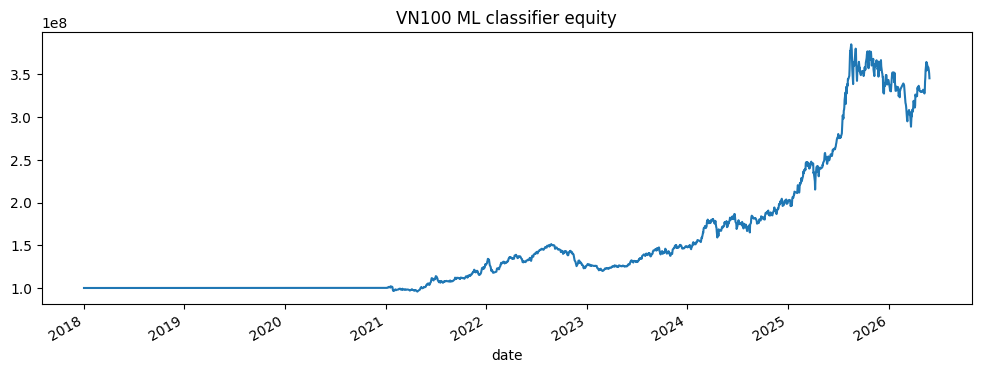

In [42]:
portfolio = vbt.Portfolio.from_orders(
    close=close_bt,
    size=weights_bt,
    size_type="TargetPercent",
    fees=FEE_RATE,
    cash_sharing=True,
    group_by=True,
    init_cash=INIT_CASH,
    freq=pd.tseries.frequencies.to_offset(close_bt.index[1] - close_bt.index[0]),
)

equity = portfolio.get_value(group_by=True).rename("equity")
returns = portfolio.get_returns(group_by=True).astype(float).rename("portfolio_return")

returns_list = returns.to_list()
equity_list = equity.to_list()
returns_std = np.std(returns_list, ddof=1)
downside = [value for value in returns_list if value < 0]
downside_std = np.std(downside, ddof=1)
running_peak = np.maximum.accumulate(equity_list)
qts_metrics = pd.Series(
    {
        "sharpe": np.mean(returns_list) / returns_std * np.sqrt(252),
        "sortino": np.mean(returns_list) / downside_std * np.sqrt(252),
        "cagr": (equity_list[-1] / equity_list[0]) ** (252 / (len(equity_list) - 1)) - 1,
        "max_drawdown": abs(np.min((np.array(equity_list) - running_peak) / running_peak)),
        "win_rate": np.mean(np.array(returns_list) > 0),
    },
    name="notebook",
)


portfolio_stats = portfolio.stats()
display(portfolio_stats.to_frame("value") if isinstance(portfolio_stats, pd.Series) else portfolio_stats)

equity.plot(figsize=(12, 4), title="VN100 ML classifier equity")
plt.show()

,value
Annual return,0.160696
Cumulative returns,2.453782
Annual volatility,0.154528
Sharpe ratio,1.041905
Calmar ratio,0.642296
Stability,0.788982
Max drawdown,-0.250191
Omega ratio,1.268871
Sortino ratio,1.543413
Skew,-0.092376


Start date,2018-01-03
End date,2026-05-29
Total months,99
,Backtest
Annual return,16.086%
Cumulative returns,245.378%
Annual volatility,15.46%
Sharpe ratio,1.04
Calmar ratio,0.64
Stability,0.79
Max drawdown,-25.019%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,25.02,2025-08-18,2026-03-23,NaT,NaN
1,20.62,2022-08-24,2023-02-28,2024-01-22,369
2,13.18,2025-03-26,2025-04-09,2025-05-12,34
3,12.12,2022-01-07,2022-01-27,2022-03-24,55
4,11.97,2024-04-02,2024-04-19,2024-06-04,46


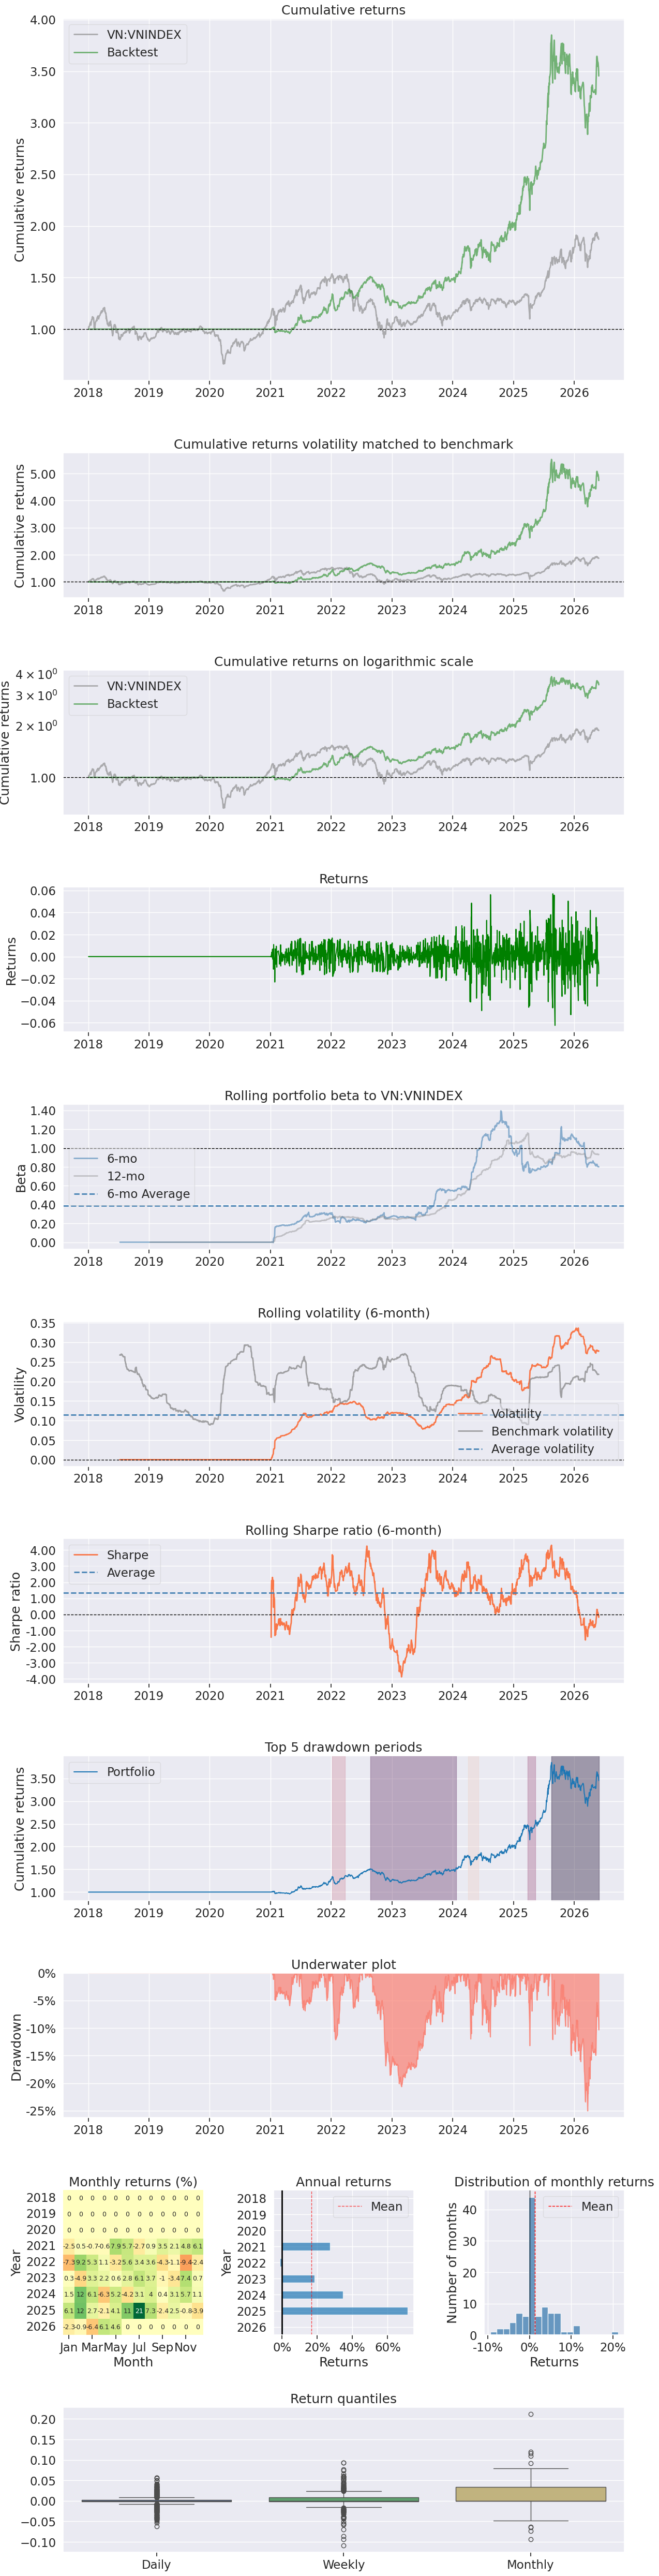

In [43]:
benchmark = benchmark_raw.select(["date", "close"]).to_pandas().drop_duplicates("date").sort_values("date")
benchmark["date"] = pd.to_datetime(benchmark["date"], utc=True)
benchmark_returns = benchmark.set_index("date")["close"].pct_change().dropna().rename(BENCHMARK)

pyfolio_returns = returns.replace([np.inf, -np.inf], np.nan).dropna()
pyfolio_returns.index = pd.to_datetime(pyfolio_returns.index, utc=True)
pyfolio_returns.name = "ml_factor_classifier"

pyfolio_stats = pf.timeseries.perf_stats(pyfolio_returns, factor_returns=benchmark_returns)
display(pyfolio_stats.to_frame("value"))

pf.create_returns_tear_sheet(pyfolio_returns, benchmark_rets=benchmark_returns)